In [1]:
import sys, os
from pathlib import Path
import warnings 
warnings.filterwarnings("ignore")

# --- robust project root detection ---
CWD = Path.cwd()
PROJECT_ROOT = next((p for p in [CWD] + list(CWD.parents) if (p / "preprocessing").exists()), None)
if PROJECT_ROOT is None:
    raise RuntimeError("Could not find PROJECT_ROOT (no 'preprocessing/' directory found in parents).")

# Make imports work + ensure relative paths are consistent
sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

print("CWD:", CWD)
print("PROJECT_ROOT:", PROJECT_ROOT)

import pandas as pd
from analysis.cox_regression import compute_hazard_ratios

from analysis.metabolite_level_analysis import (
    analyse_with_logistic_regression,
    calculate_odds_ratio,
    calculate_hazard_ratio,
    prepare_duration,
    create_ages_df,
    create_ages_df_with_df
)

from preprocessing import (
    MetaboliteLevelsPreprocessorFactory,
    PathwayPreprocessorFactory,
    ReactionPreprocessorFactory,
    MetabolitePathwayCombinedPreprocessorFactory,
    MetaboliteReactionCombinedPreprocessorFactory,
    TranscriptomicsPreprocessorFactory,
    TranscriptomicsMetabolitePreprocessorFactory,
    TranscriptomicsPathwayPreprocessorFactory,
    TranscriptomicsReactionPreprocessorFactory
)
from sklearn.preprocessing import StandardScaler

CWD: /home/bioinformatics/Desktop/alzheimer_analysis/notebooks
PROJECT_ROOT: /home/bioinformatics/Desktop/alzheimer_analysis


In [2]:
from analysis.config import make_default_paths
# dataset root
DATA_DIR = PROJECT_ROOT / "ROSMAP-AD"
paths = make_default_paths(DATA_DIR)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)
metabolite_levels_file_path = paths.metabolite_levels_file_path
prs_combined = paths.prs_combined_path
pathway_file_path = paths.pathway_file_path
reaction_file_path = paths.reaction_file_path
metabolite_level_pathway_combined_file_path = paths.metabolite_level_pathway_combined_file_path
metabolite_level_reaction_combined_file_path = paths.metabolite_level_reaction_combined_file_path
x_pathway_path = paths.x_pathway_path
x_reaction_path = paths.x_reaction_path
best_prs_path = paths.best_prs_path
clinical_ages_path = paths.clinical_ages_path

PROJECT_ROOT: /home/bioinformatics/Desktop/alzheimer_analysis
DATA_DIR: /home/bioinformatics/Desktop/alzheimer_analysis/ROSMAP-AD


In [8]:
from pathlib import Path
import os
from analysis import calculate_risk_score_with_prs
import glob

hazard_ratio_list = {}

# Path to the main folder
main_folder = 'ROSMAP-AD/Final_Prs_Scores'
factory_list = [
    MetaboliteLevelsPreprocessorFactory(metabolite_levels_file_path),
    PathwayPreprocessorFactory(metabolite_levels_file_path, pathway_file_path, x_pathway_path),
    ReactionPreprocessorFactory(metabolite_levels_file_path, reaction_file_path, x_reaction_path),
    MetabolitePathwayCombinedPreprocessorFactory(metabolite_levels_file_path, metabolite_level_pathway_combined_file_path, x_pathway_path),
    MetaboliteReactionCombinedPreprocessorFactory(metabolite_levels_file_path, metabolite_level_reaction_combined_file_path, x_reaction_path),
]
# Loop through each subfolder
for subfolder in os.listdir(main_folder):
    subfolder_path = os.path.join(main_folder, subfolder)
    hazard_ratios = {}
    # Check if it's a directory
    if os.path.isdir(subfolder_path):
        prs_id = subfolder
        csv_path = os.path.join(subfolder_path, 'prs_scores.csv')
        prs_scores = pd.read_csv(csv_path)               # Contains individual IDs and scores
        rosmap_clinical = pd.read_csv('ROSMAP-AD/raw/clinical.csv')     # Contains ID, Study, and projid

        # Merge on individual ID
        rosmap_clinical['sample_id'] = rosmap_clinical['Sample ID'].astype(str)
        merged = prs_scores.merge(rosmap_clinical, on='sample_id', how='inner')
        prs_df = merged[['sample_id', 'score']]

        for factory in factory_list:
            preprocessor = factory.create_preprocessor()
            y, risk_scores, sample_ids_ = analyse_with_logistic_regression(preprocessor)
            ages_df = create_ages_df(preprocessor.file_path, clinical_ages_path)
            duration_df = prepare_duration(ages_df)

            hr = compute_hazard_ratios(risk_scores, duration_df)
            hazard_ratios[preprocessor.name] = hr

            combined_risk_df = calculate_risk_score_with_prs(y, risk_scores, sample_ids_, prs_df, prs_combined)
            ages_prs = create_ages_df_with_df(combined_risk_df['sample_id_biomarker'], clinical_ages_path, metabolite_levels_file_path)
            duration_prs = prepare_duration(ages_prs)
            hr_with_prs = compute_hazard_ratios(combined_risk_df['combined_score'], duration_prs)

            hazard_ratios[preprocessor.name + " PRS"] = hr_with_prs
        scaler = StandardScaler()
        prs_df.loc[:, "score"] = scaler.fit_transform(prs_df[["score"]])

        ages_prs_ = create_ages_df_with_df(prs_df["sample_id"], clinical_ages_path, metabolite_levels_file_path)
        duration_prs_ = prepare_duration(ages_prs_)
        hr_prs = compute_hazard_ratios(prs_df['score'], duration_prs_)
        hazard_ratios["Prs Score " + prs_id] = hr_prs
        hazard_ratio_list[prs_id] = hazard_ratios

Log(HR) (coef): 0.9568988523014174
Hazard Ratio (exp(coef)): 2.6036097624386474
P-value: 1.1252257555370838e-05
Log(HR) (coef): 0.8420189531255823
Hazard Ratio (exp(coef)): 2.3210483372623782
P-value: 0.00015369164397406205
Log(HR) (coef): 0.7694314900290189
Hazard Ratio (exp(coef)): 2.1585387540906185
P-value: 0.00048394783487012467
Log(HR) (coef): 0.594571449666231
Hazard Ratio (exp(coef)): 1.8122541364062317
P-value: 0.010746031204669012
Log(HR) (coef): 0.9861502348579926
Hazard Ratio (exp(coef)): 2.680893769099462
P-value: 4.41958690387124e-06
Log(HR) (coef): 1.0762844037672328
Hazard Ratio (exp(coef)): 2.9337586122826016
P-value: 1.4635889400400746e-06
Log(HR) (coef): 1.1782861938662619
Hazard Ratio (exp(coef)): 3.248801612952639
P-value: 5.0282355539751626e-08
Log(HR) (coef): 0.9045529097504209
Hazard Ratio (exp(coef)): 2.4708269934170892
P-value: 4.874057015699742e-05
Log(HR) (coef): 0.9265428806251375
Hazard Ratio (exp(coef)): 2.5257622052097823
P-value: 1.5804244184616656e-05


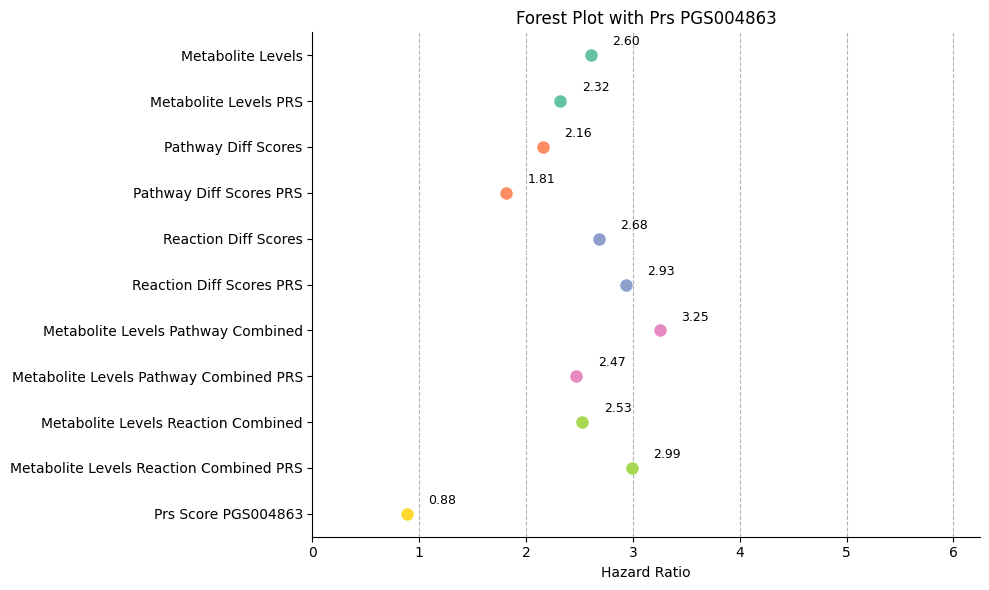

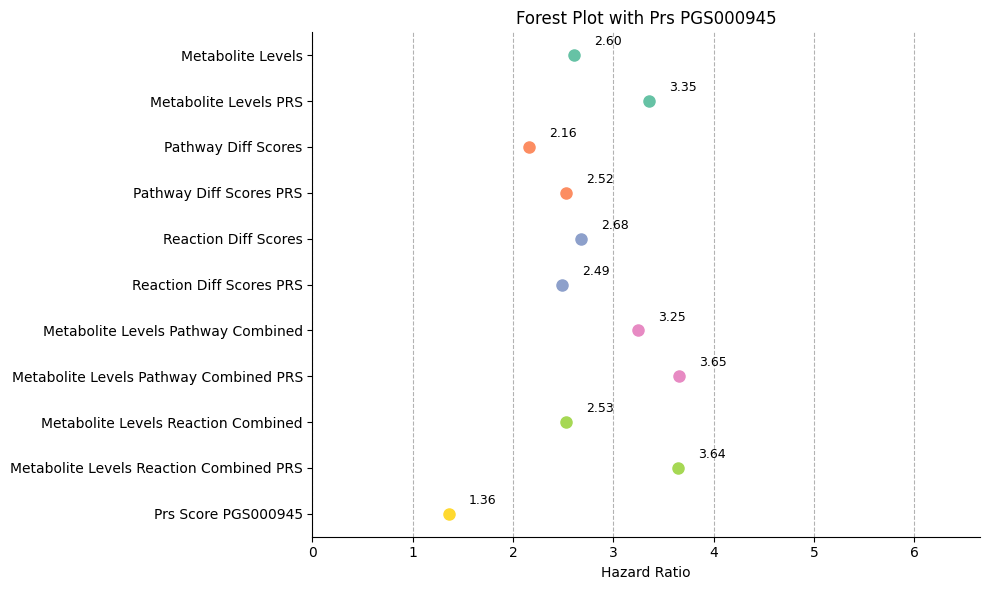

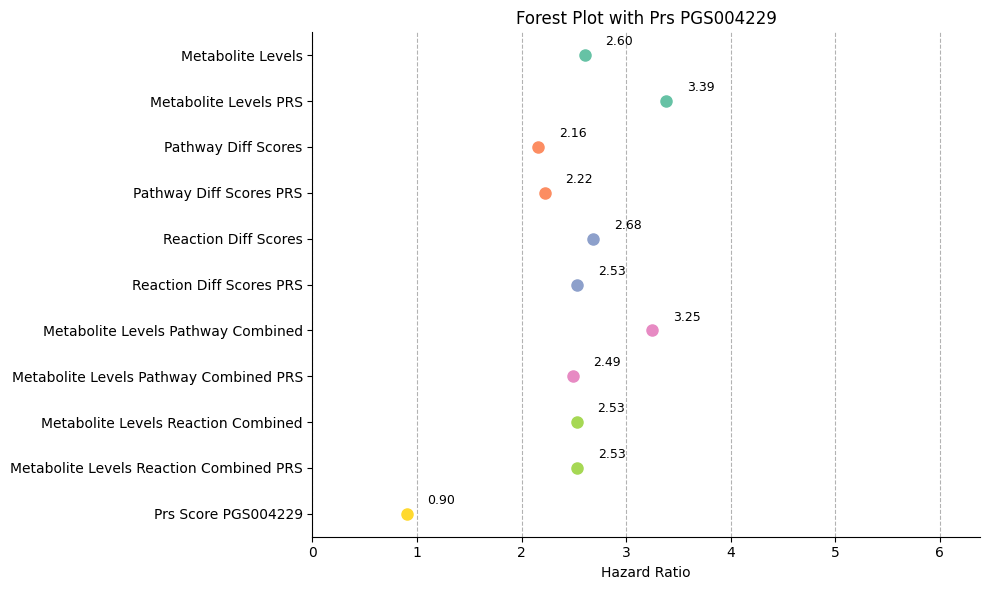

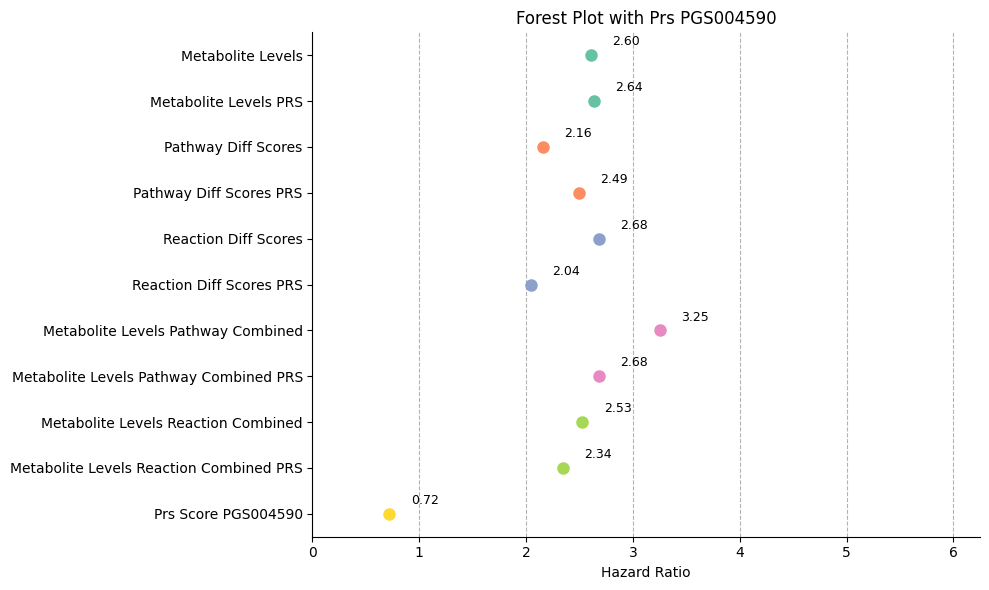

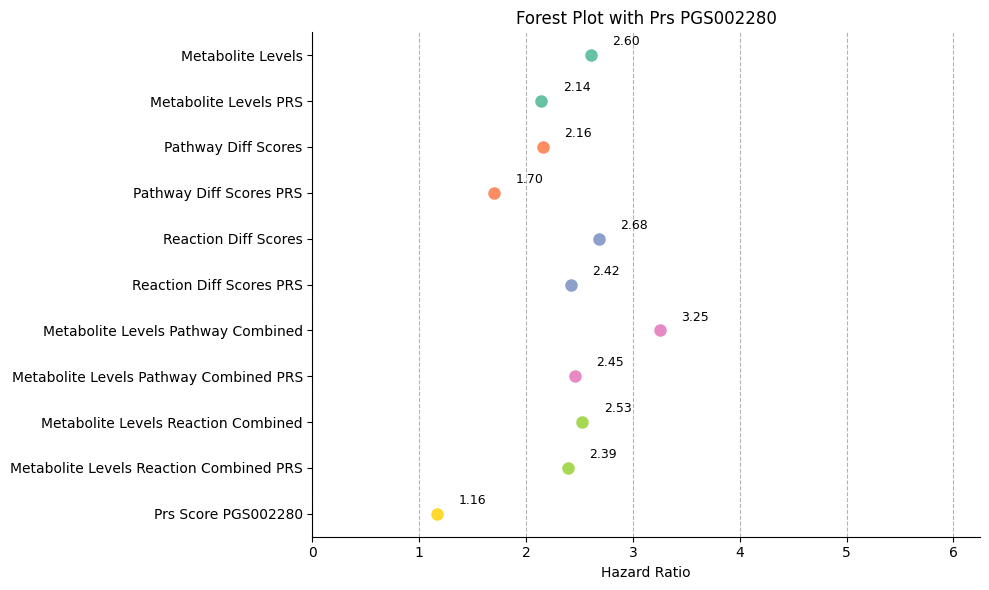

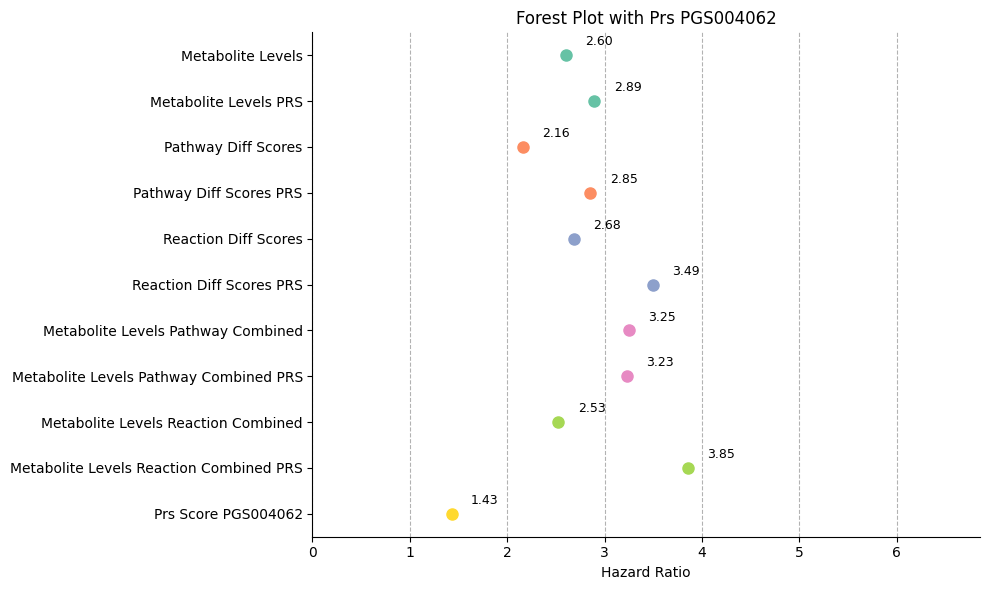

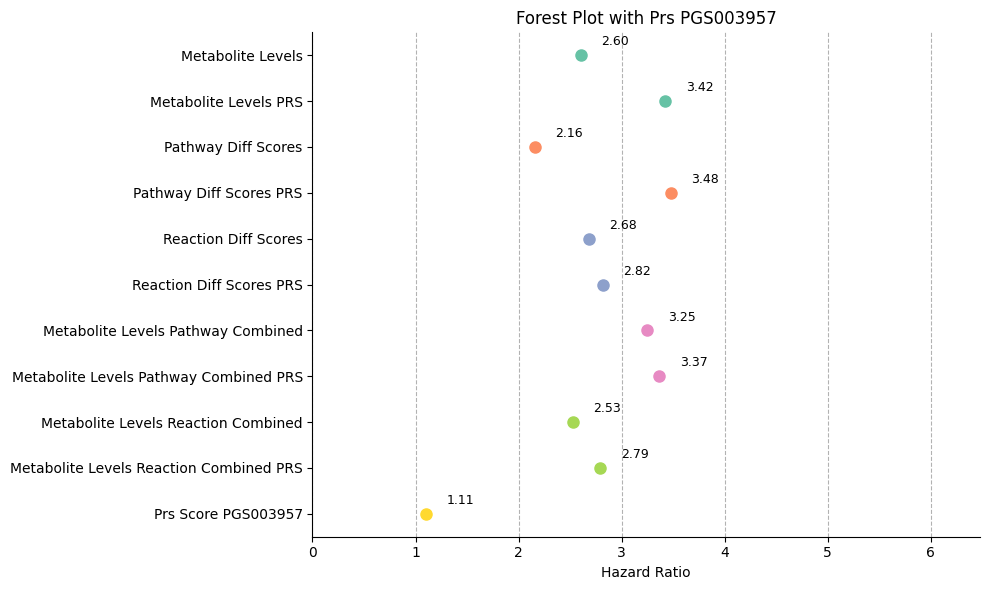

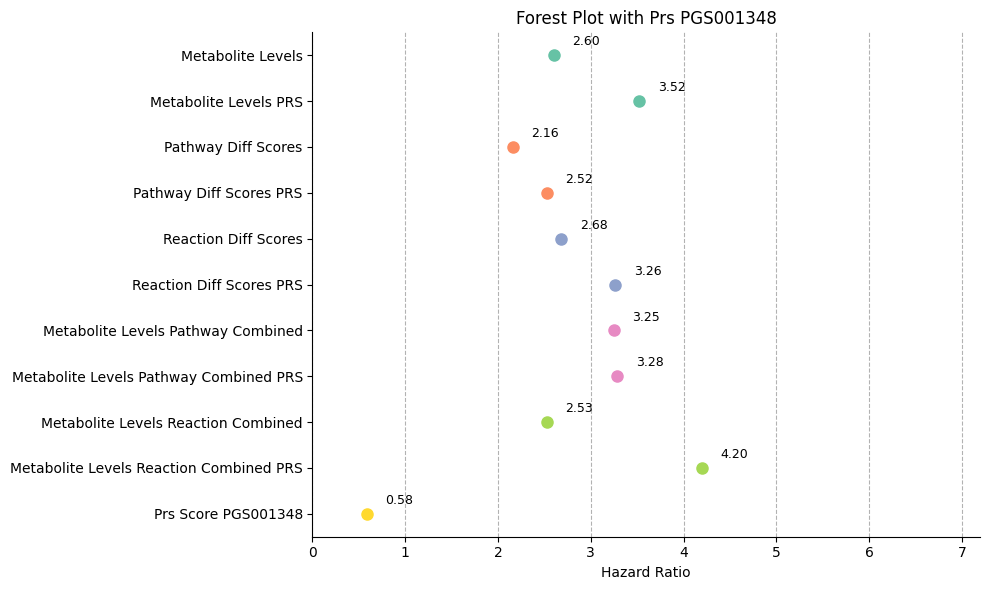

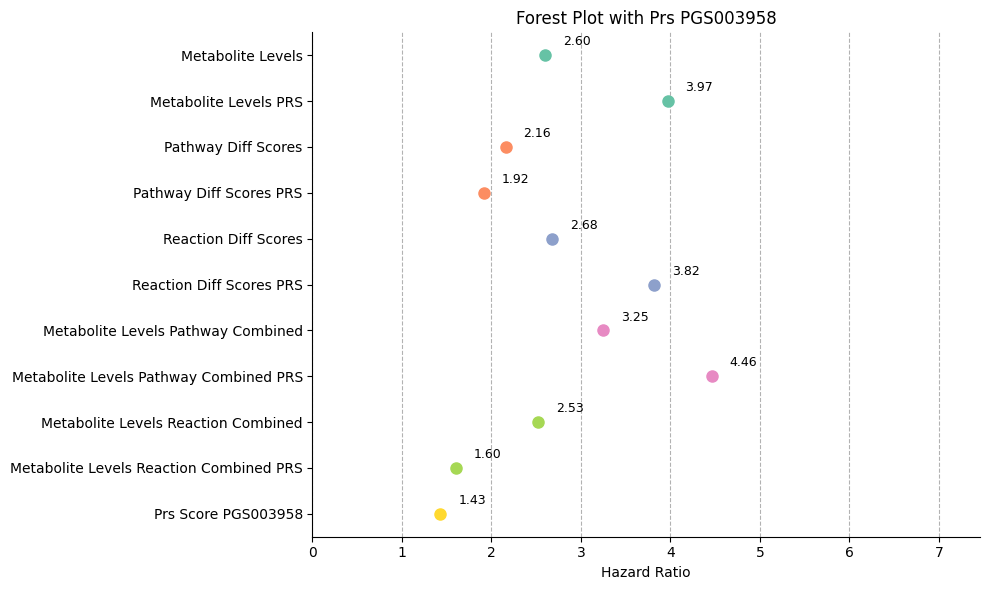

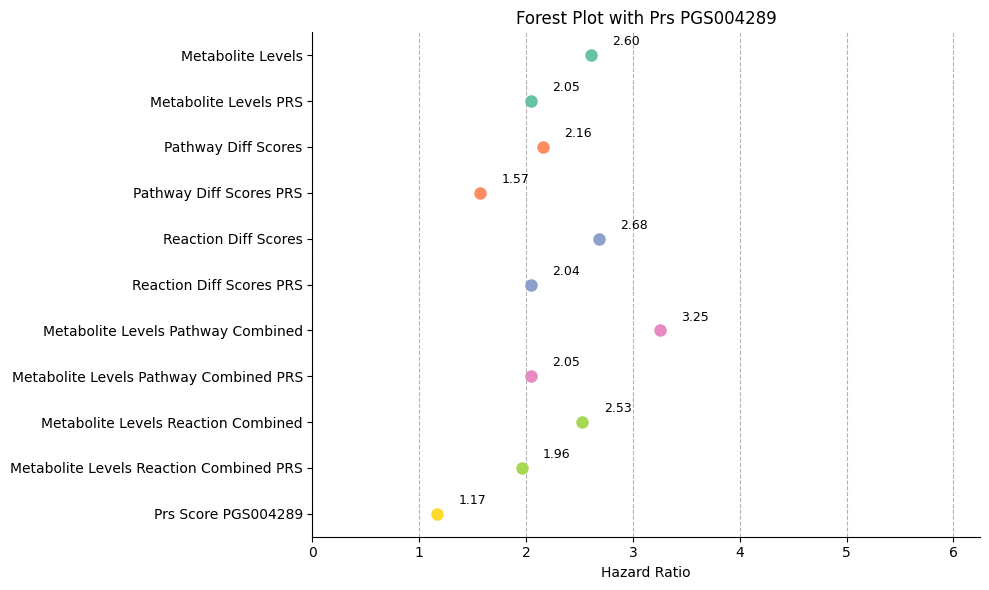

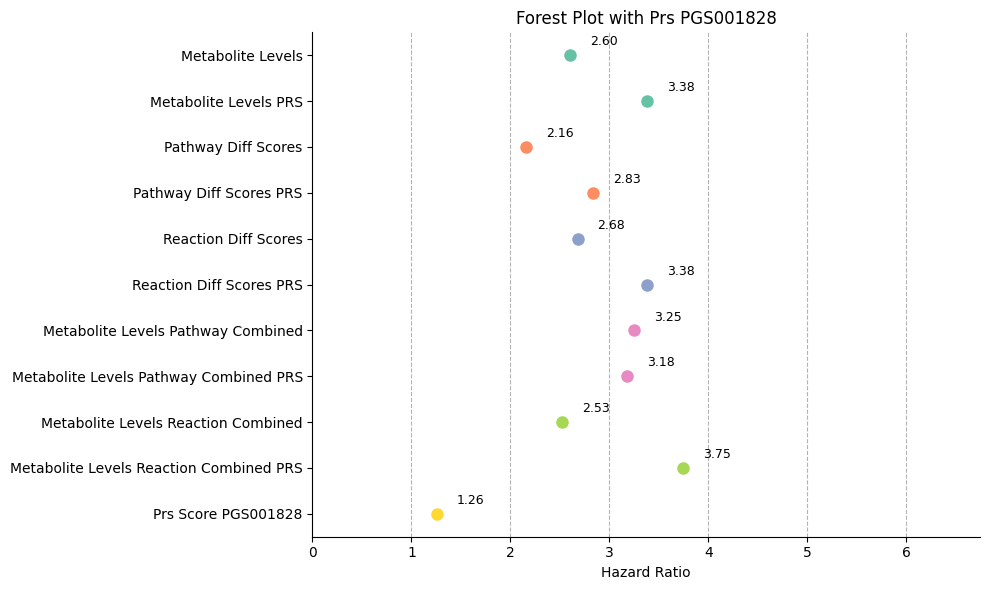

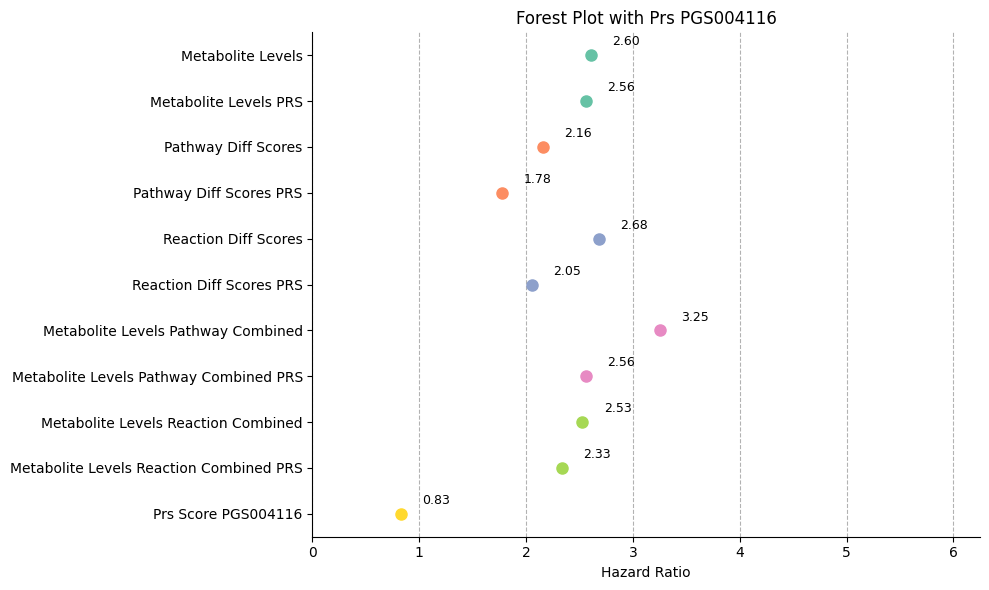

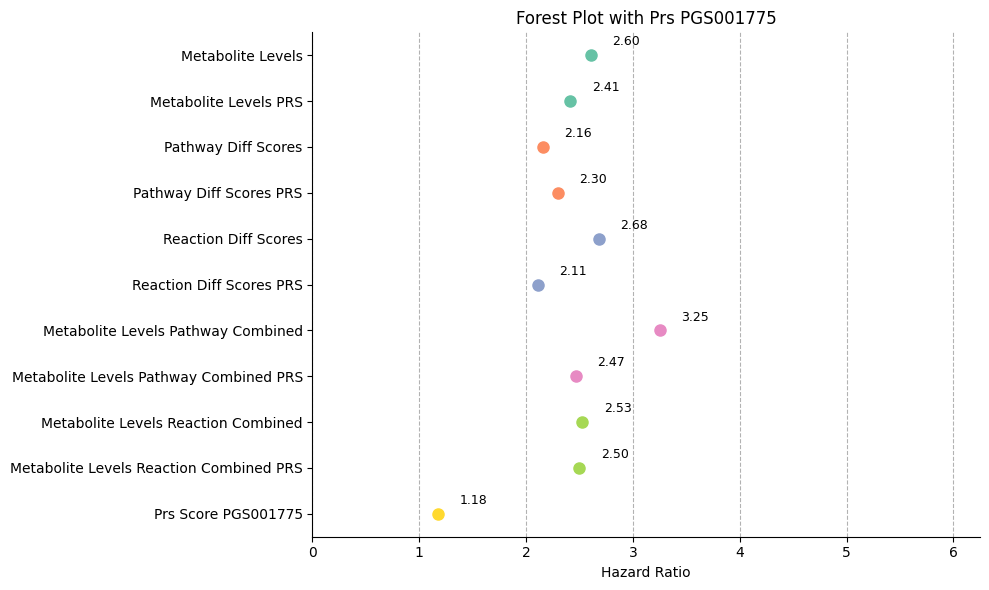

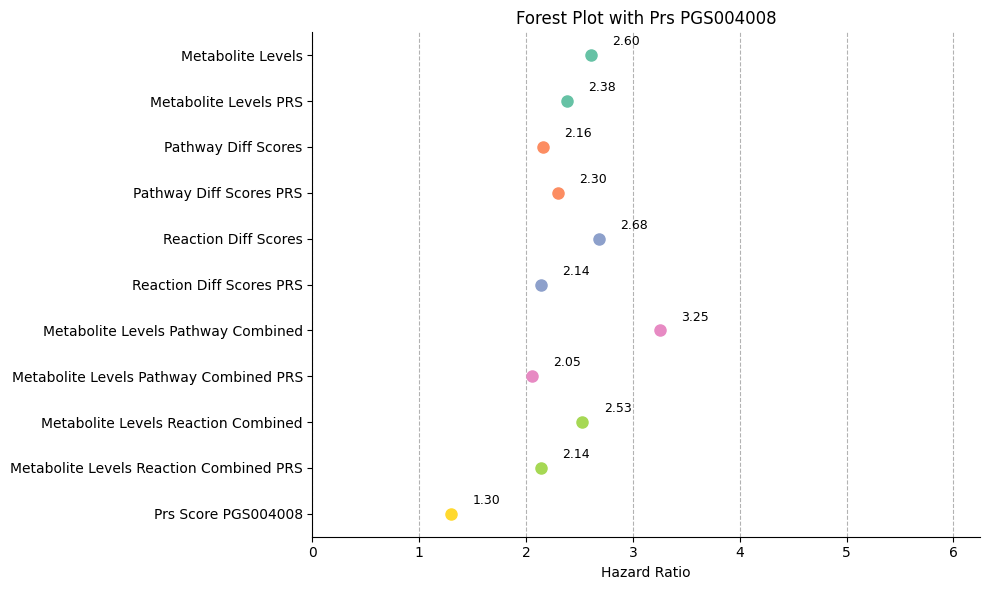

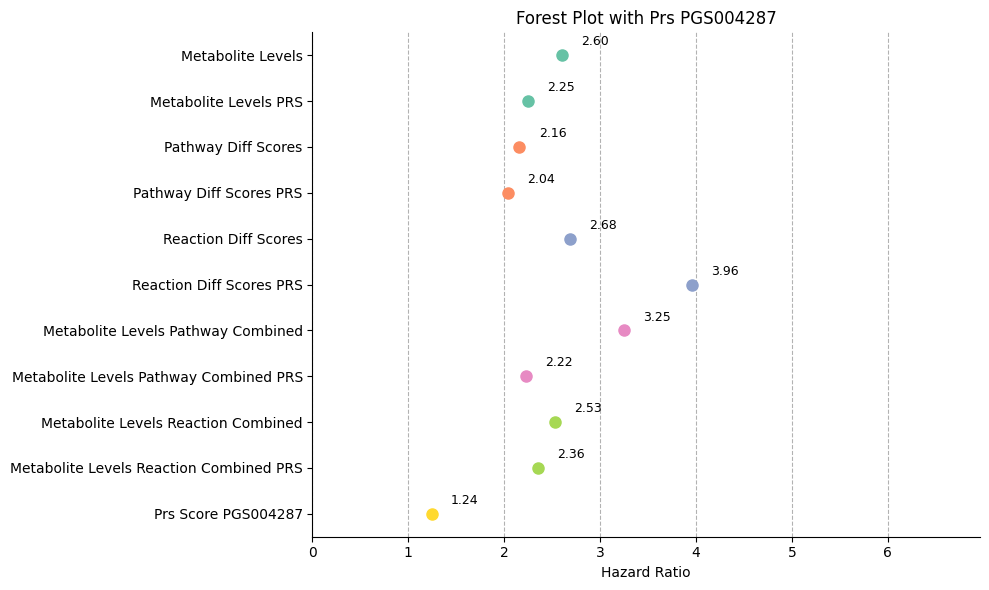

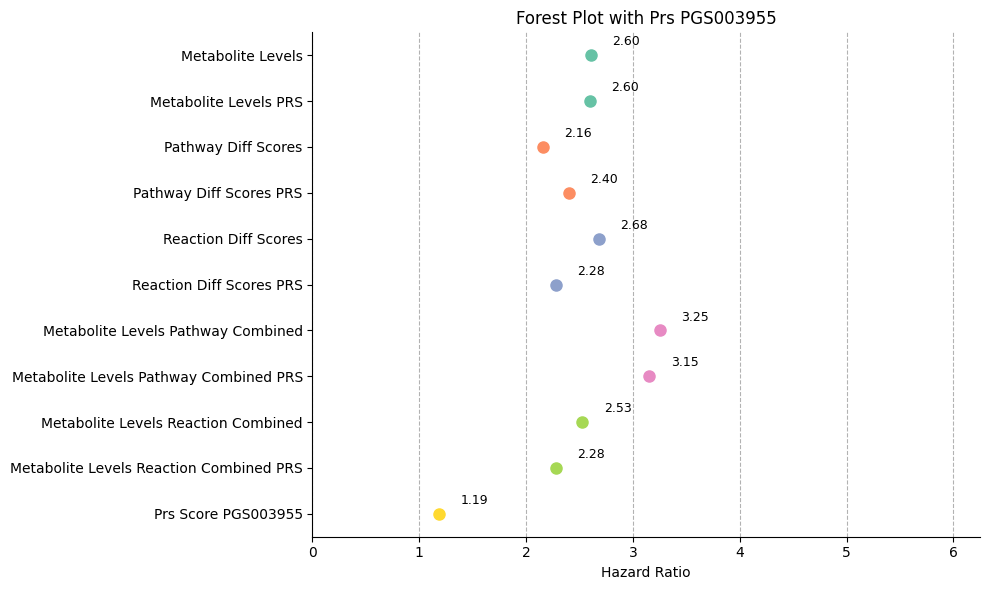

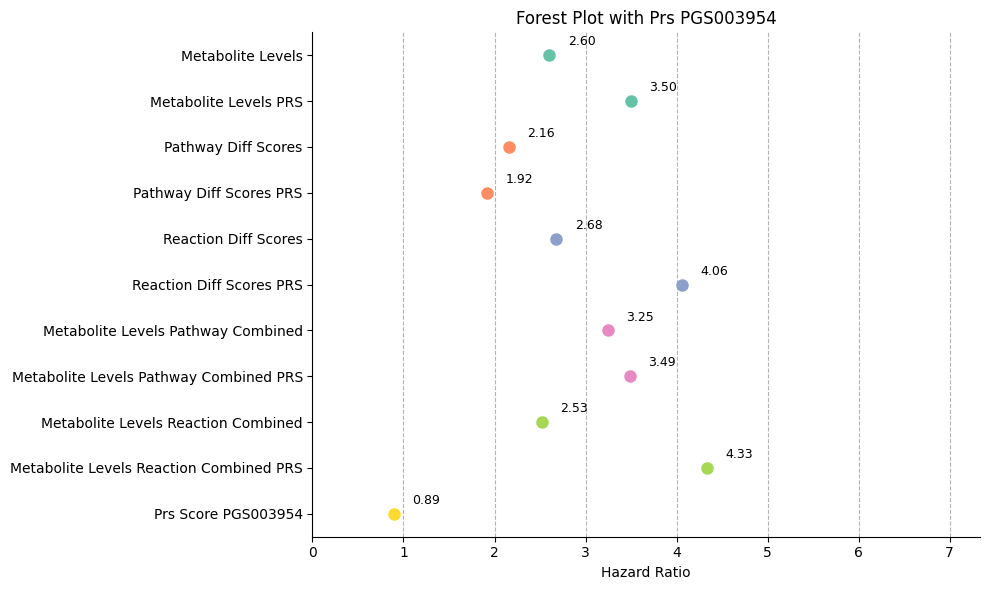

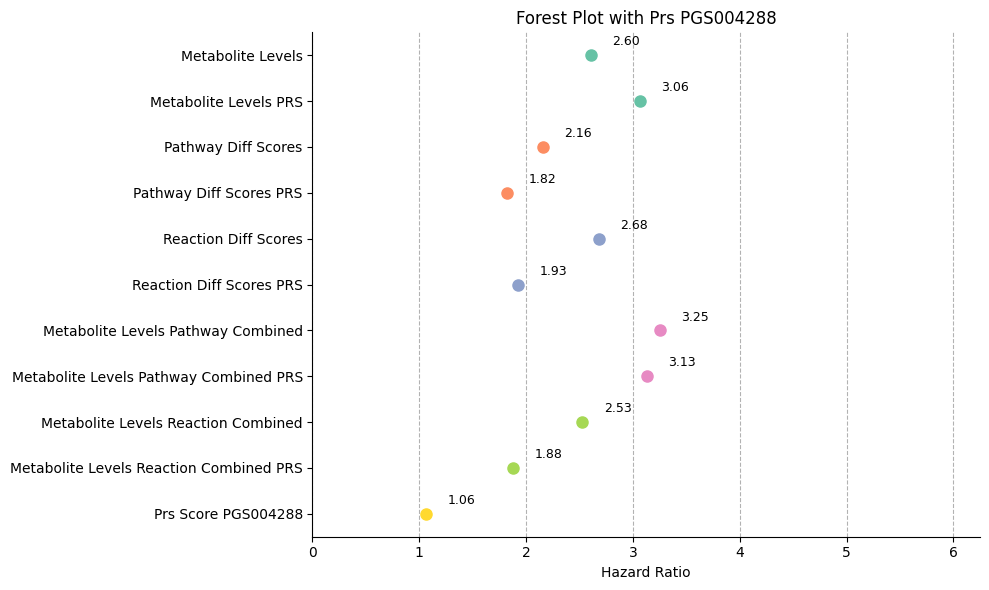

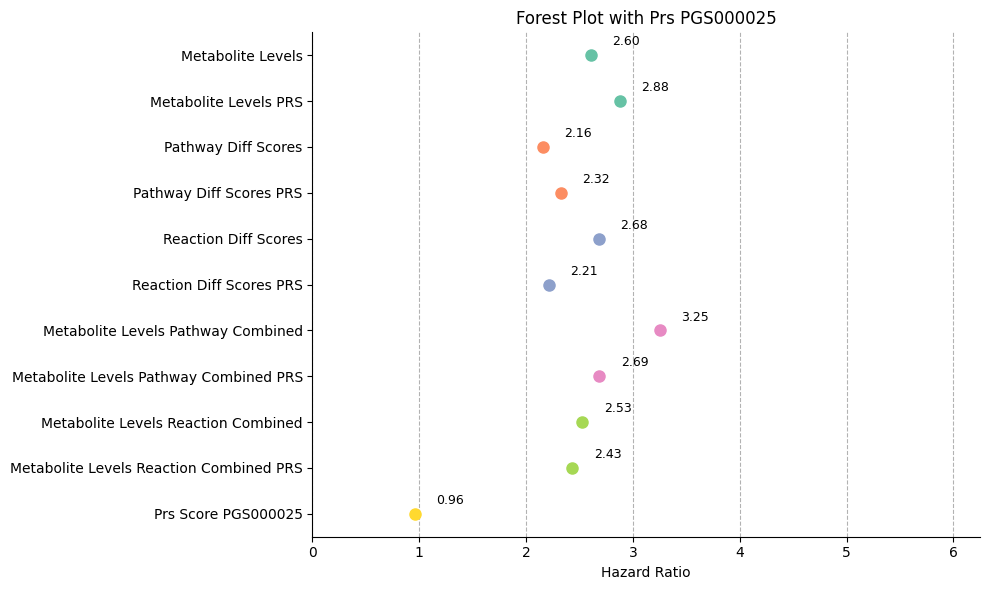

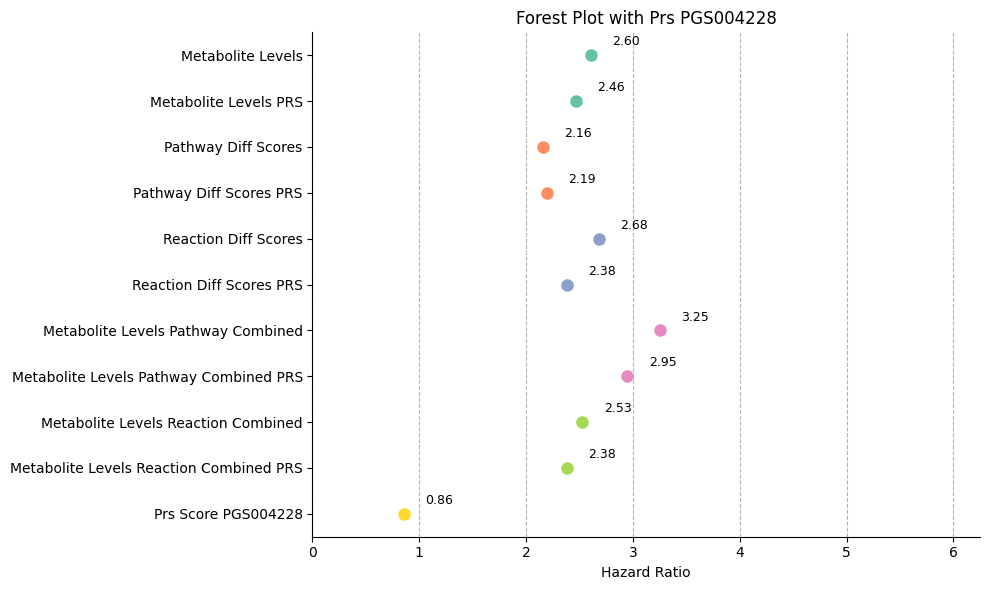

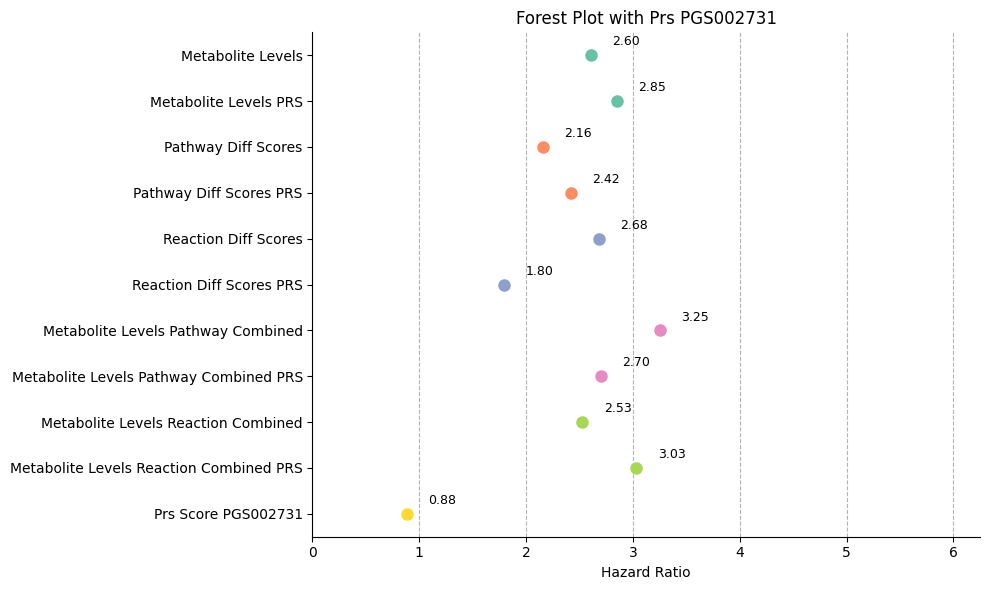

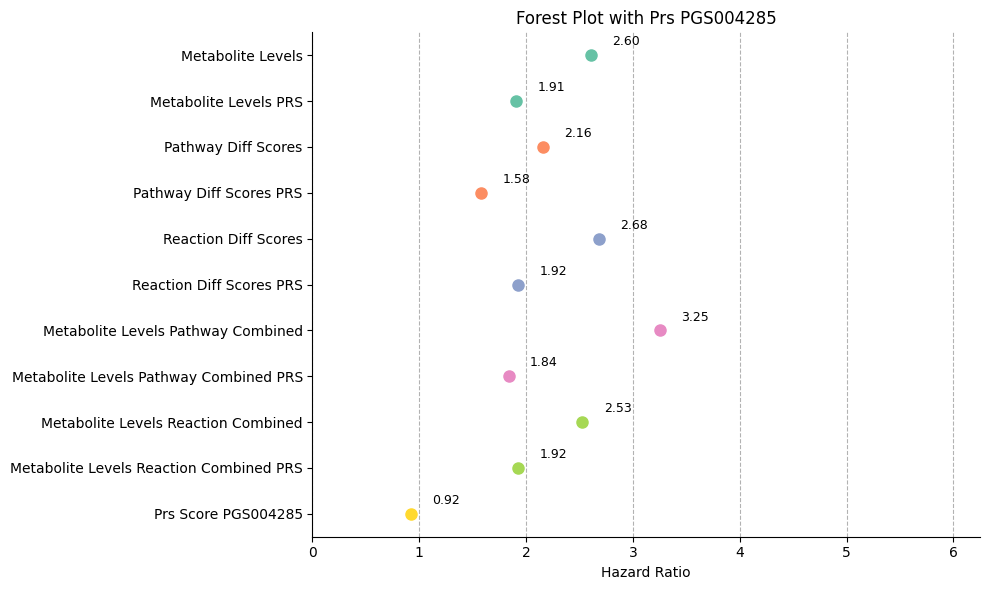

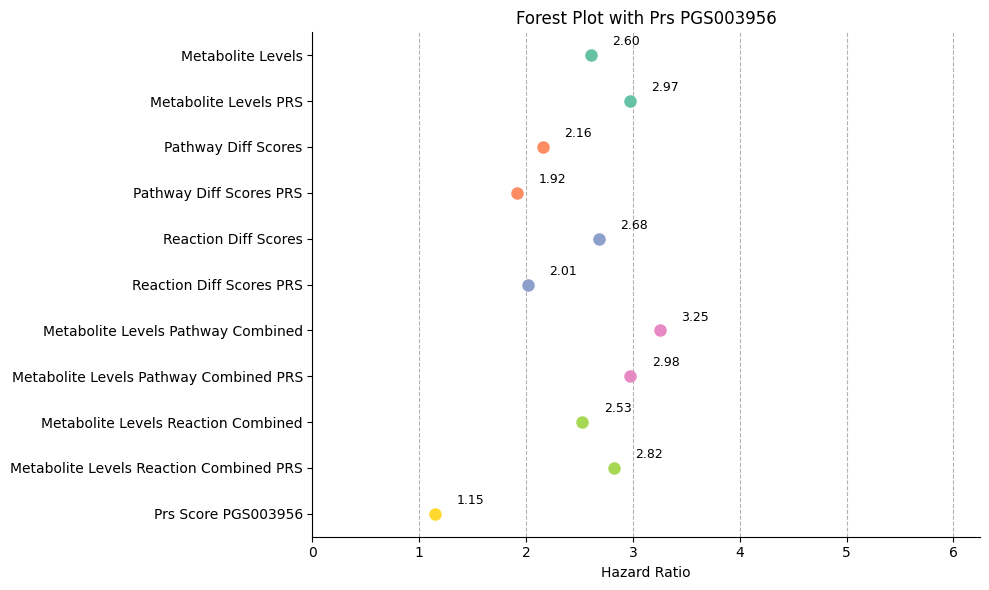

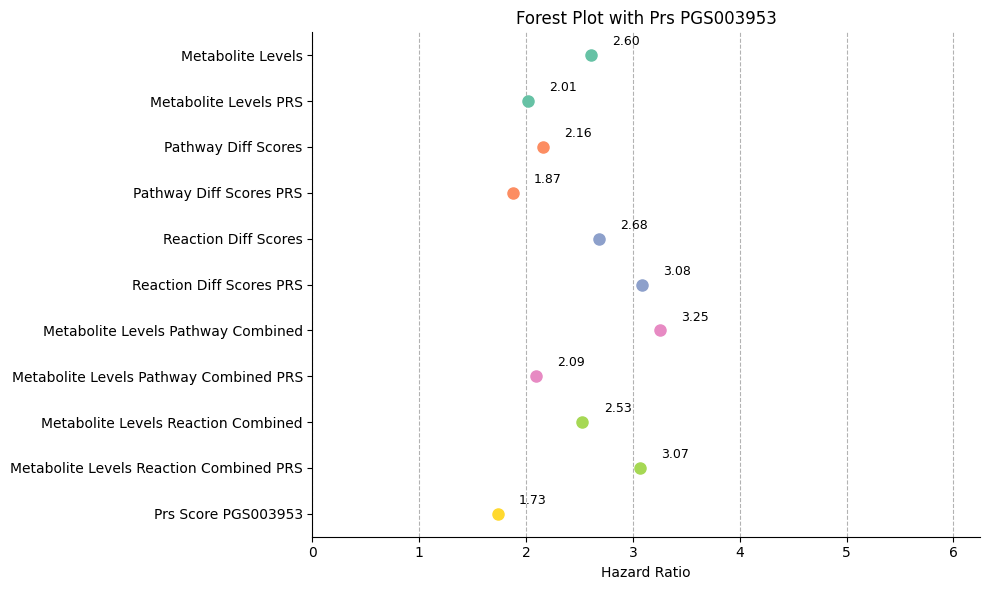

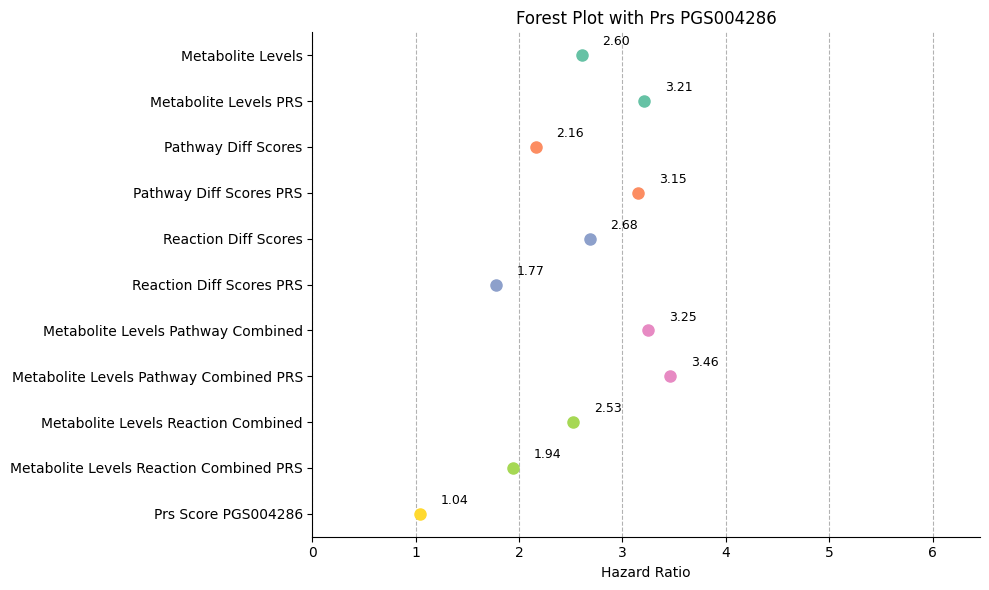

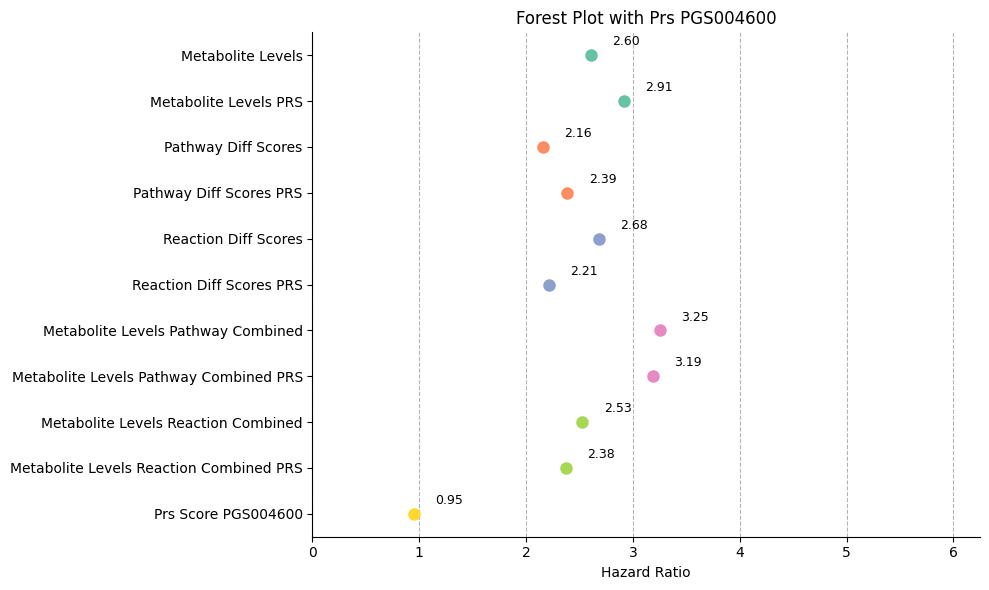

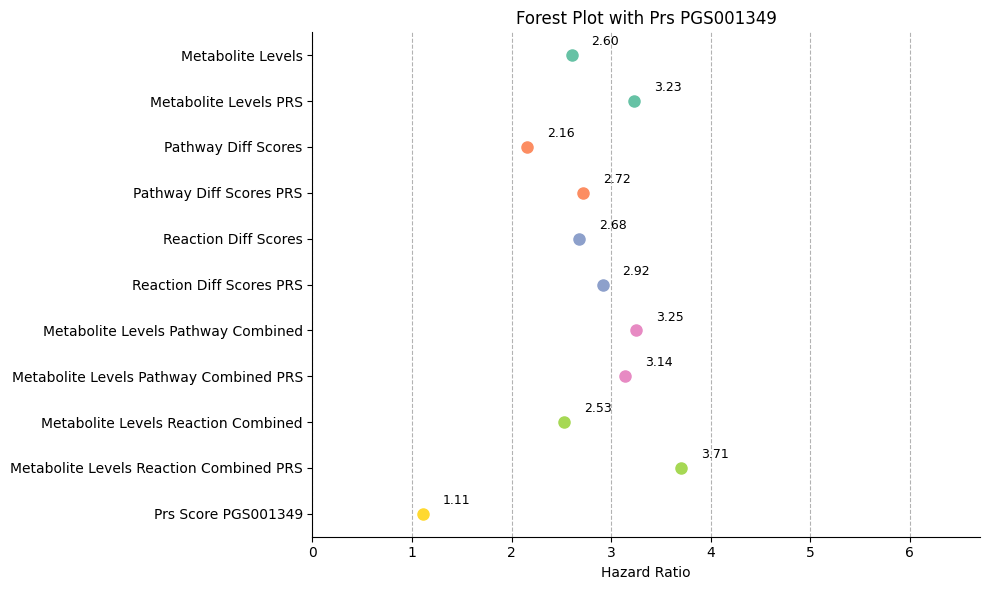

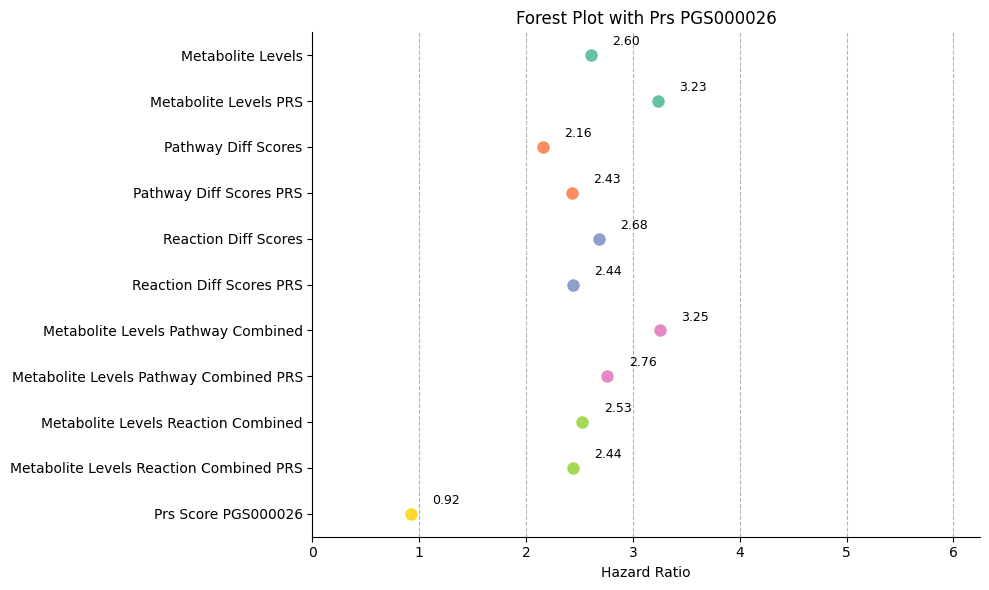

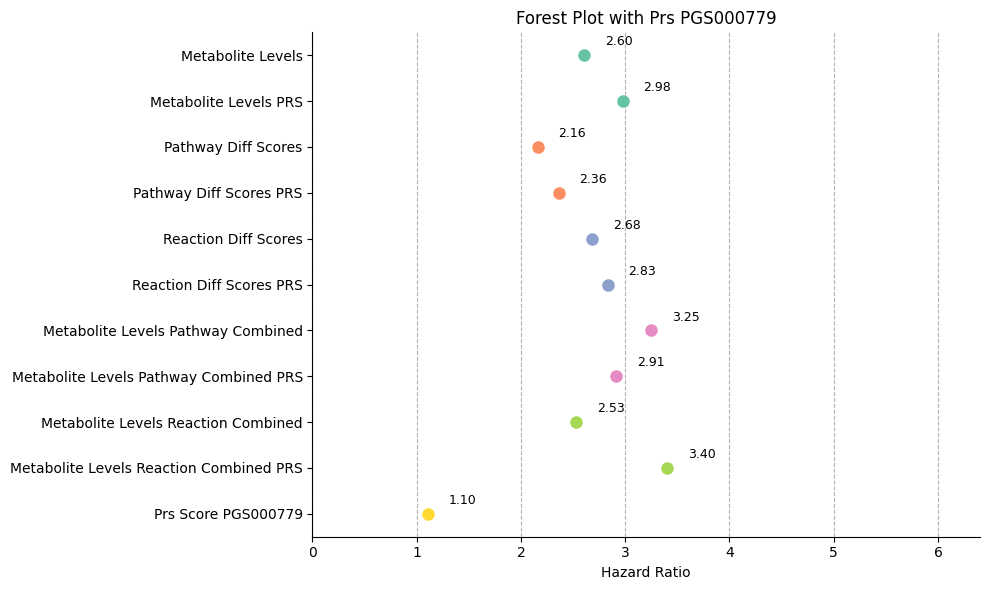

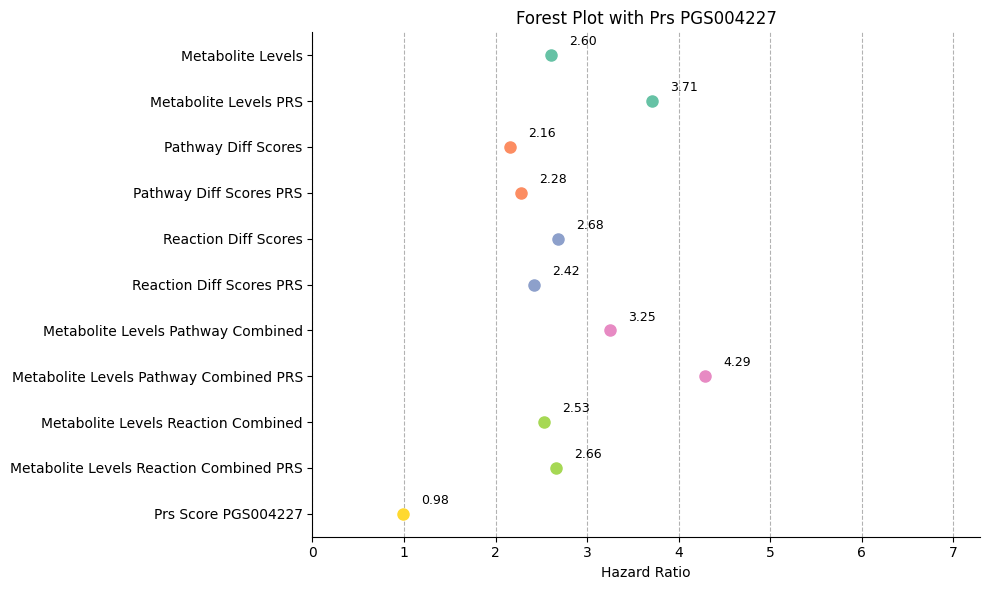

In [10]:
import matplotlib.pyplot as plt
import numpy as np
for subfolder in os.listdir(main_folder):
    if '.DS_Store' == subfolder:
        continue
    labels = list(hazard_ratio_list[subfolder].keys())
    odds_ratios = np.array(list(hazard_ratio_list[subfolder].values()))

    fig, ax = plt.subplots(figsize=(10, 6))
    fig.patch.set_facecolor('white')  # Set figure background to white
    ax.set_facecolor('white')         # Set axes background to white

    y_pos = np.arange(len(labels))
    colors = plt.cm.Set2.colors  # Light, pastel colors

    for i, (odds, label) in enumerate(zip(odds_ratios, labels)):
        color = colors[(i // 2) % len(colors)]  # Use same color for pairs (0-1, 2-3, ...)
        ax.plot(odds, y_pos[i], 'o', color=color, markersize=8)
        ax.text(odds + 0.2, y_pos[i] - 0.15, f"{odds:.2f}",
                va='bottom', ha='left', fontsize=9, color='black')

    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, color='black')
    ax.invert_yaxis()
    ax.set_xlabel("Hazard Ratio", color='black')
    ax.set_title("Forest Plot with Prs " + subfolder, color='black')
    ax.set_xlim(0, max(odds_ratios) + 3)

    # Only vertical grid lines
    ax.grid(True, axis='x', linestyle='--', alpha=0.6, color='gray')

    # Optional: remove top/right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.tick_params(colors='black')

    plt.tight_layout()

    output_path = os.path.join("plots/ROSMAP-AD/hazard_ratios", f"forest_plot_{subfolder}.png")
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    plt.savefig(output_path, dpi=300, facecolor='white')  # Save with white background

    plt.show()


In [11]:
import os
import csv
output_file = 'ROSMAP-AD/processed/hazard_ratios.csv'
# Get all unique labels from the first valid subfolder to use as headers
for subfolder in os.listdir(main_folder):
    if '.DS_Store' == subfolder:
        continue
    if subfolder in hazard_ratio_list:
        labels = list(hazard_ratio_list[subfolder].keys())
        break

# Open the file and write headers and rows
with open(output_file, mode='w', newline='') as file:

    writer = csv.writer(file)

    # Write header
    header = ['PRS name'] + labels
    writer.writerow(header)

    # Write each row
    for subfolder in os.listdir(main_folder):
        if subfolder not in hazard_ratio_list or '.DS_Store' == subfolder:
            continue
        labels = list(hazard_ratio_list[subfolder].keys())
        odds_ratios = np.array(list(hazard_ratio_list[subfolder].values()))
        row = [subfolder] + list(odds_ratios)
        writer.writerow(row)

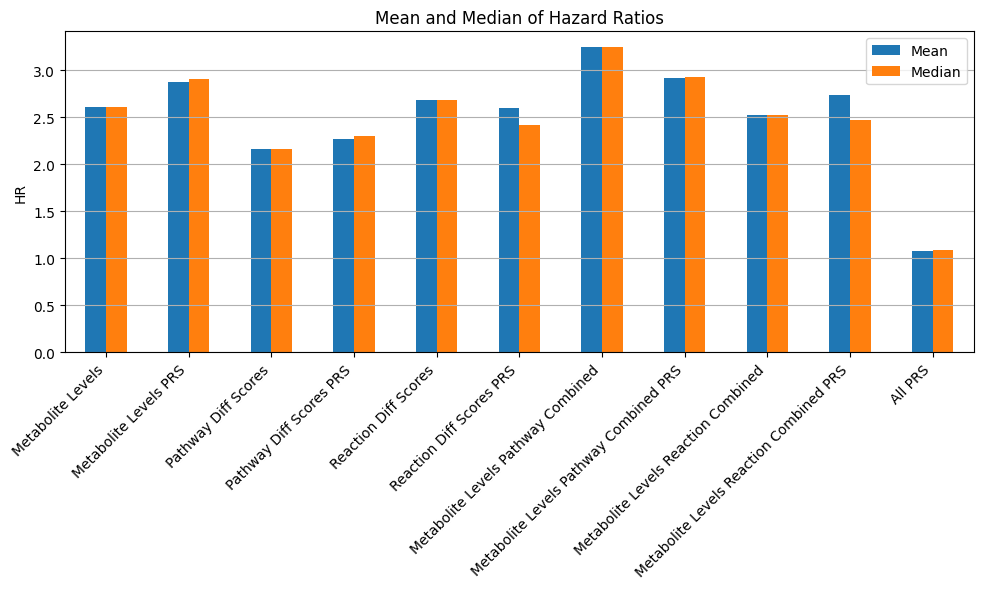

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

hazard_ratios = pd.read_csv(output_file)

data = hazard_ratios.iloc[:, 1:]
means = data.mean()
medians = data.median()

stats_df = pd.DataFrame({
    'Mean': means,
    'Median': medians
})

ax = stats_df.plot(kind='bar', figsize=(10, 6))
plt.title('Mean and Median of Hazard Ratios')
plt.ylabel('HR')

labels = list(stats_df.index)
labels[-1] = 'All PRS'

ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha='right')

plt.grid(axis='y')
plt.subplots_adjust(bottom=0.25)
plt.tight_layout()
plt.show()


In [13]:
# Keep the first column (e.g., an ID or label) for reference
first_col = hazard_ratios.columns[0]
row_labels = hazard_ratios[first_col]

# Data excluding the first column
data = hazard_ratios.iloc[:, 1:]

# Find the column name with the maximum value for each row
max_columns = data.idxmax(axis=1)

# Combine with the first column for context (optional)
result = pd.DataFrame({
    first_col: row_labels,
    'Max_Column': max_columns
})

# Print the result
print(result)

     PRS name                               Max_Column
0   PGS004863       Metabolite Levels Pathway Combined
1   PGS000945   Metabolite Levels Pathway Combined PRS
2   PGS004229                    Metabolite Levels PRS
3   PGS004590       Metabolite Levels Pathway Combined
4   PGS002280       Metabolite Levels Pathway Combined
5   PGS004062  Metabolite Levels Reaction Combined PRS
6   PGS003957                  Pathway Diff Scores PRS
7   PGS001348  Metabolite Levels Reaction Combined PRS
8   PGS003958   Metabolite Levels Pathway Combined PRS
9   PGS004289       Metabolite Levels Pathway Combined
10  PGS001828  Metabolite Levels Reaction Combined PRS
11  PGS004116       Metabolite Levels Pathway Combined
12  PGS001775       Metabolite Levels Pathway Combined
13  PGS004008       Metabolite Levels Pathway Combined
14  PGS004287                 Reaction Diff Scores PRS
15  PGS003955       Metabolite Levels Pathway Combined
16  PGS003954  Metabolite Levels Reaction Combined PRS
17  PGS004

     PRS name                               Max_Column  \
0   PGS004863       Metabolite Levels Pathway Combined   
1   PGS000945   Metabolite Levels Pathway Combined PRS   
2   PGS004229                    Metabolite Levels PRS   
3   PGS004590       Metabolite Levels Pathway Combined   
4   PGS002280       Metabolite Levels Pathway Combined   
5   PGS004062  Metabolite Levels Reaction Combined PRS   
6   PGS003957                  Pathway Diff Scores PRS   
7   PGS001348  Metabolite Levels Reaction Combined PRS   
8   PGS003958   Metabolite Levels Pathway Combined PRS   
9   PGS004289       Metabolite Levels Pathway Combined   
10  PGS001828  Metabolite Levels Reaction Combined PRS   
11  PGS004116       Metabolite Levels Pathway Combined   
12  PGS001775       Metabolite Levels Pathway Combined   
13  PGS004008       Metabolite Levels Pathway Combined   
14  PGS004287                 Reaction Diff Scores PRS   
15  PGS003955       Metabolite Levels Pathway Combined   
16  PGS003954 

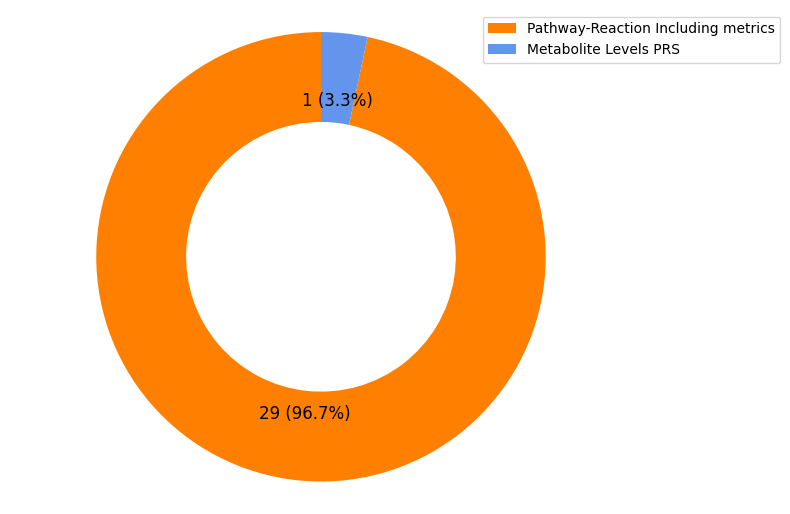

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Simulated data (replace this with reading your actual DataFrame)


# Categorize each row into the two new classes
def categorize_two_classes(column_value):
    if column_value == 'Metabolite Levels PRS':
        return 'Metabolite Levels PRS'
    elif 'Pathway' in column_value or 'Reaction' in column_value:
        return 'Pathway-Reaction Including metrics'
    else:
        # Fallback for any unexpected values, though ideally all should fall into the above
        return 'Other'

result['Group'] = result['Max_Column'].apply(categorize_two_classes)
print(result)
# Count the categories
group_counts = result['Group'].value_counts()

# Define specific colors for the two classes (you can adjust these as desired)
colors = {
    'Metabolite Levels PRS': '#6495ED',  # A shade of blue
    'Pathway-Reaction Including metrics': '#FF7F00' # A shade of gold/yellow
}

# Ensure the colors are in the correct order for the pie chart slices
pie_colors = [colors[label] for label in group_counts.index]

plt.figure(figsize=(8, 5.7))

# Create the doughnut chart
wedges, texts, autotexts = plt.pie(group_counts,
                                   colors=pie_colors,
                                   wedgeprops=dict(width=0.4), # Controls the size of the hole
                                   startangle=90, # Start angle for the first slice
                                   autopct='', # We will manually add text
                                   pctdistance=0.85) # Distance of percentage text from center

# Manually add text (count and percentage) inside the slices
total = sum(group_counts)
for i, p in enumerate(wedges):
    ang = (p.theta2 - p.theta1)/2. + p.theta1
    # Adjust 0.7 to move text closer/further from center
    x = p.r * 0.7 * plt.np.cos(plt.np.deg2rad(ang))
    y = p.r * 0.7 * plt.np.sin(plt.np.deg2rad(ang))

    count = group_counts.iloc[i]
    percentage = (count / total) * 100

    if percentage > 0: # Only show labels for slices that exist
        plt.text(x, y, f'{count} ({percentage:.1f}%)', ha='center', va='center', color='black', fontsize=12)


# Add a legend outside the plot
plt.legend(wedges, group_counts.index, title="", loc="upper right", bbox_to_anchor=(1.25, 1))

# Set the title below the chart


plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout(rect=[0, 0.08, 1, 1]) # Adjust layout to make space for the title below and legend

plt.show()
